# **PROYECTO DEL MÓDULO 5**

**Tema: Predicción de Rotación de Empleados (Attrition)**
+ **Idea principal**: Predecir si un empleado dejará la empresa.
+ **Base de datos**: IBM HR Analytics Employee Attrition (Kaggle - 1,470 empleados).
+ **Modelos**: Regresión logística penalizada, Random Forest, AdaBoost, XGBoost y MLP.

**Integrantes**:

*   Betancourt Peralta Diego
*   Canul Hernández Erick Iván
*   José Omar Gutiérrez Gutiérrez
*   Hernández Pérez Maximiliano
*   Torres Vargas Brenda Poulette


# **Exploración y Preprocesamiento.**

Cargamos las librerías necesarias.

In [ ]:
# Librerías
import pandas as pd
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
# sklearn
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, ParameterGrid)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, balanced_accuracy_score,
                             roc_auc_score,
                             classification_report, confusion_matrix)
# tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
# Definimos función para barra de progreso
import contextlib
import joblib
from tqdm.auto import tqdm

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar given as argument"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

Cargamos los datos

In [ ]:
# Cargar datos
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

## Exploración de datos

In [ ]:
# Vistazo al cabezal del dataset
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Resumen de cada variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
# Clonación y verificación de dimensiones
total_records = len(df)
print(f"Estructura de la base: {df.shape[0]} observaciones y {df.shape[1]} variables.")

# Exploración de datos faltantes
print(f"Valores faltantes detectados: {df.isnull().sum().sum()}.")

# Determinamos columnas numéricas y categóricas
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print(f"Tipos de datos: {len(num_cols)} numéricas y {len(cat_cols)} categóricas.")

Estructura de la base: 1470 observaciones y 35 variables.
Valores faltantes detectados: 0.
Tipos de datos: 26 numéricas y 9 categóricas.


**Valores Faltantes**

In [ ]:
# Muestra la cantidad de valores faltantes en cada columna
valores_faltantes = df.isnull().sum()
print(valores_faltantes[valores_faltantes > 0])  # Filtra para ver solo las que tienen nulos

Series([], dtype: int64)


<Axes: >

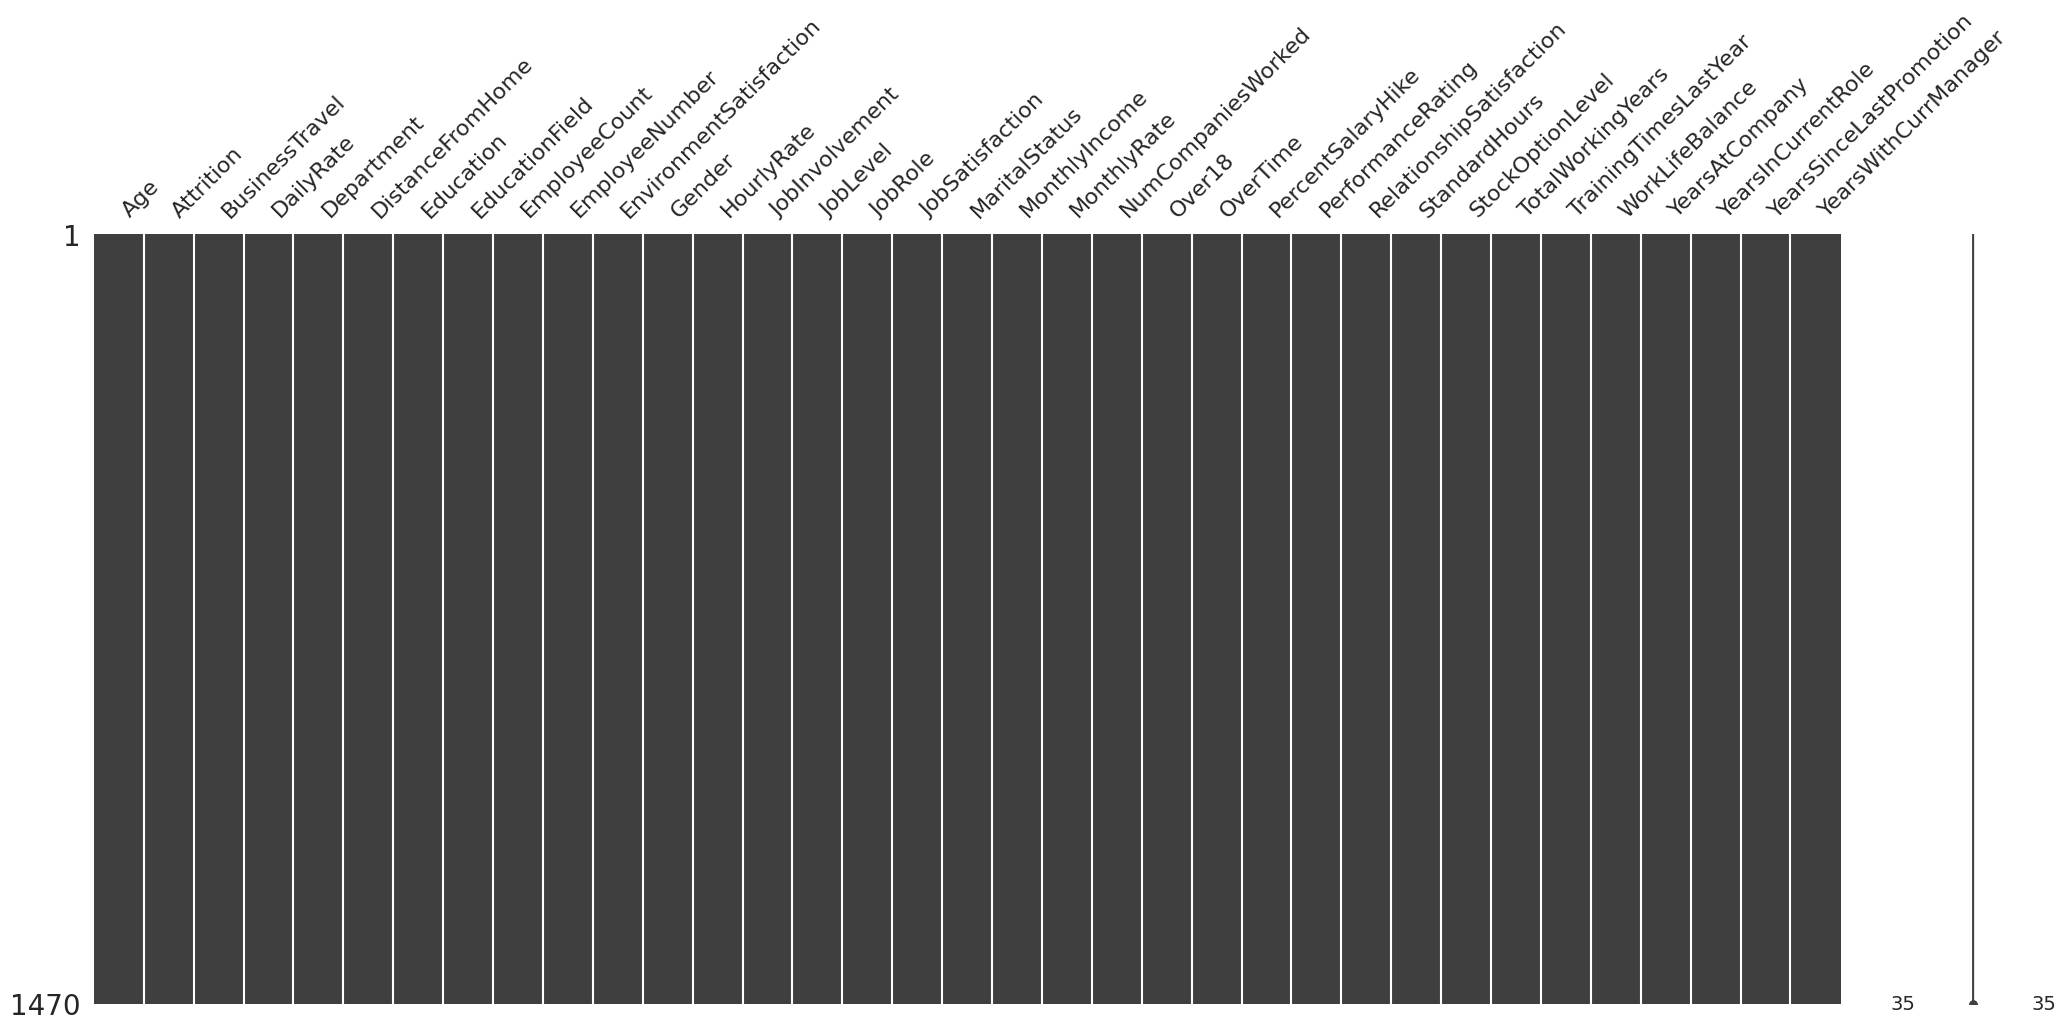

In [ ]:
# Visualización de valores faltantes en cada columna
import missingno as msno
msno.matrix(df)

**Variables numéricas**

In [ ]:
# Resumen descriptivo de columnas numéricas
df[num_cols].describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


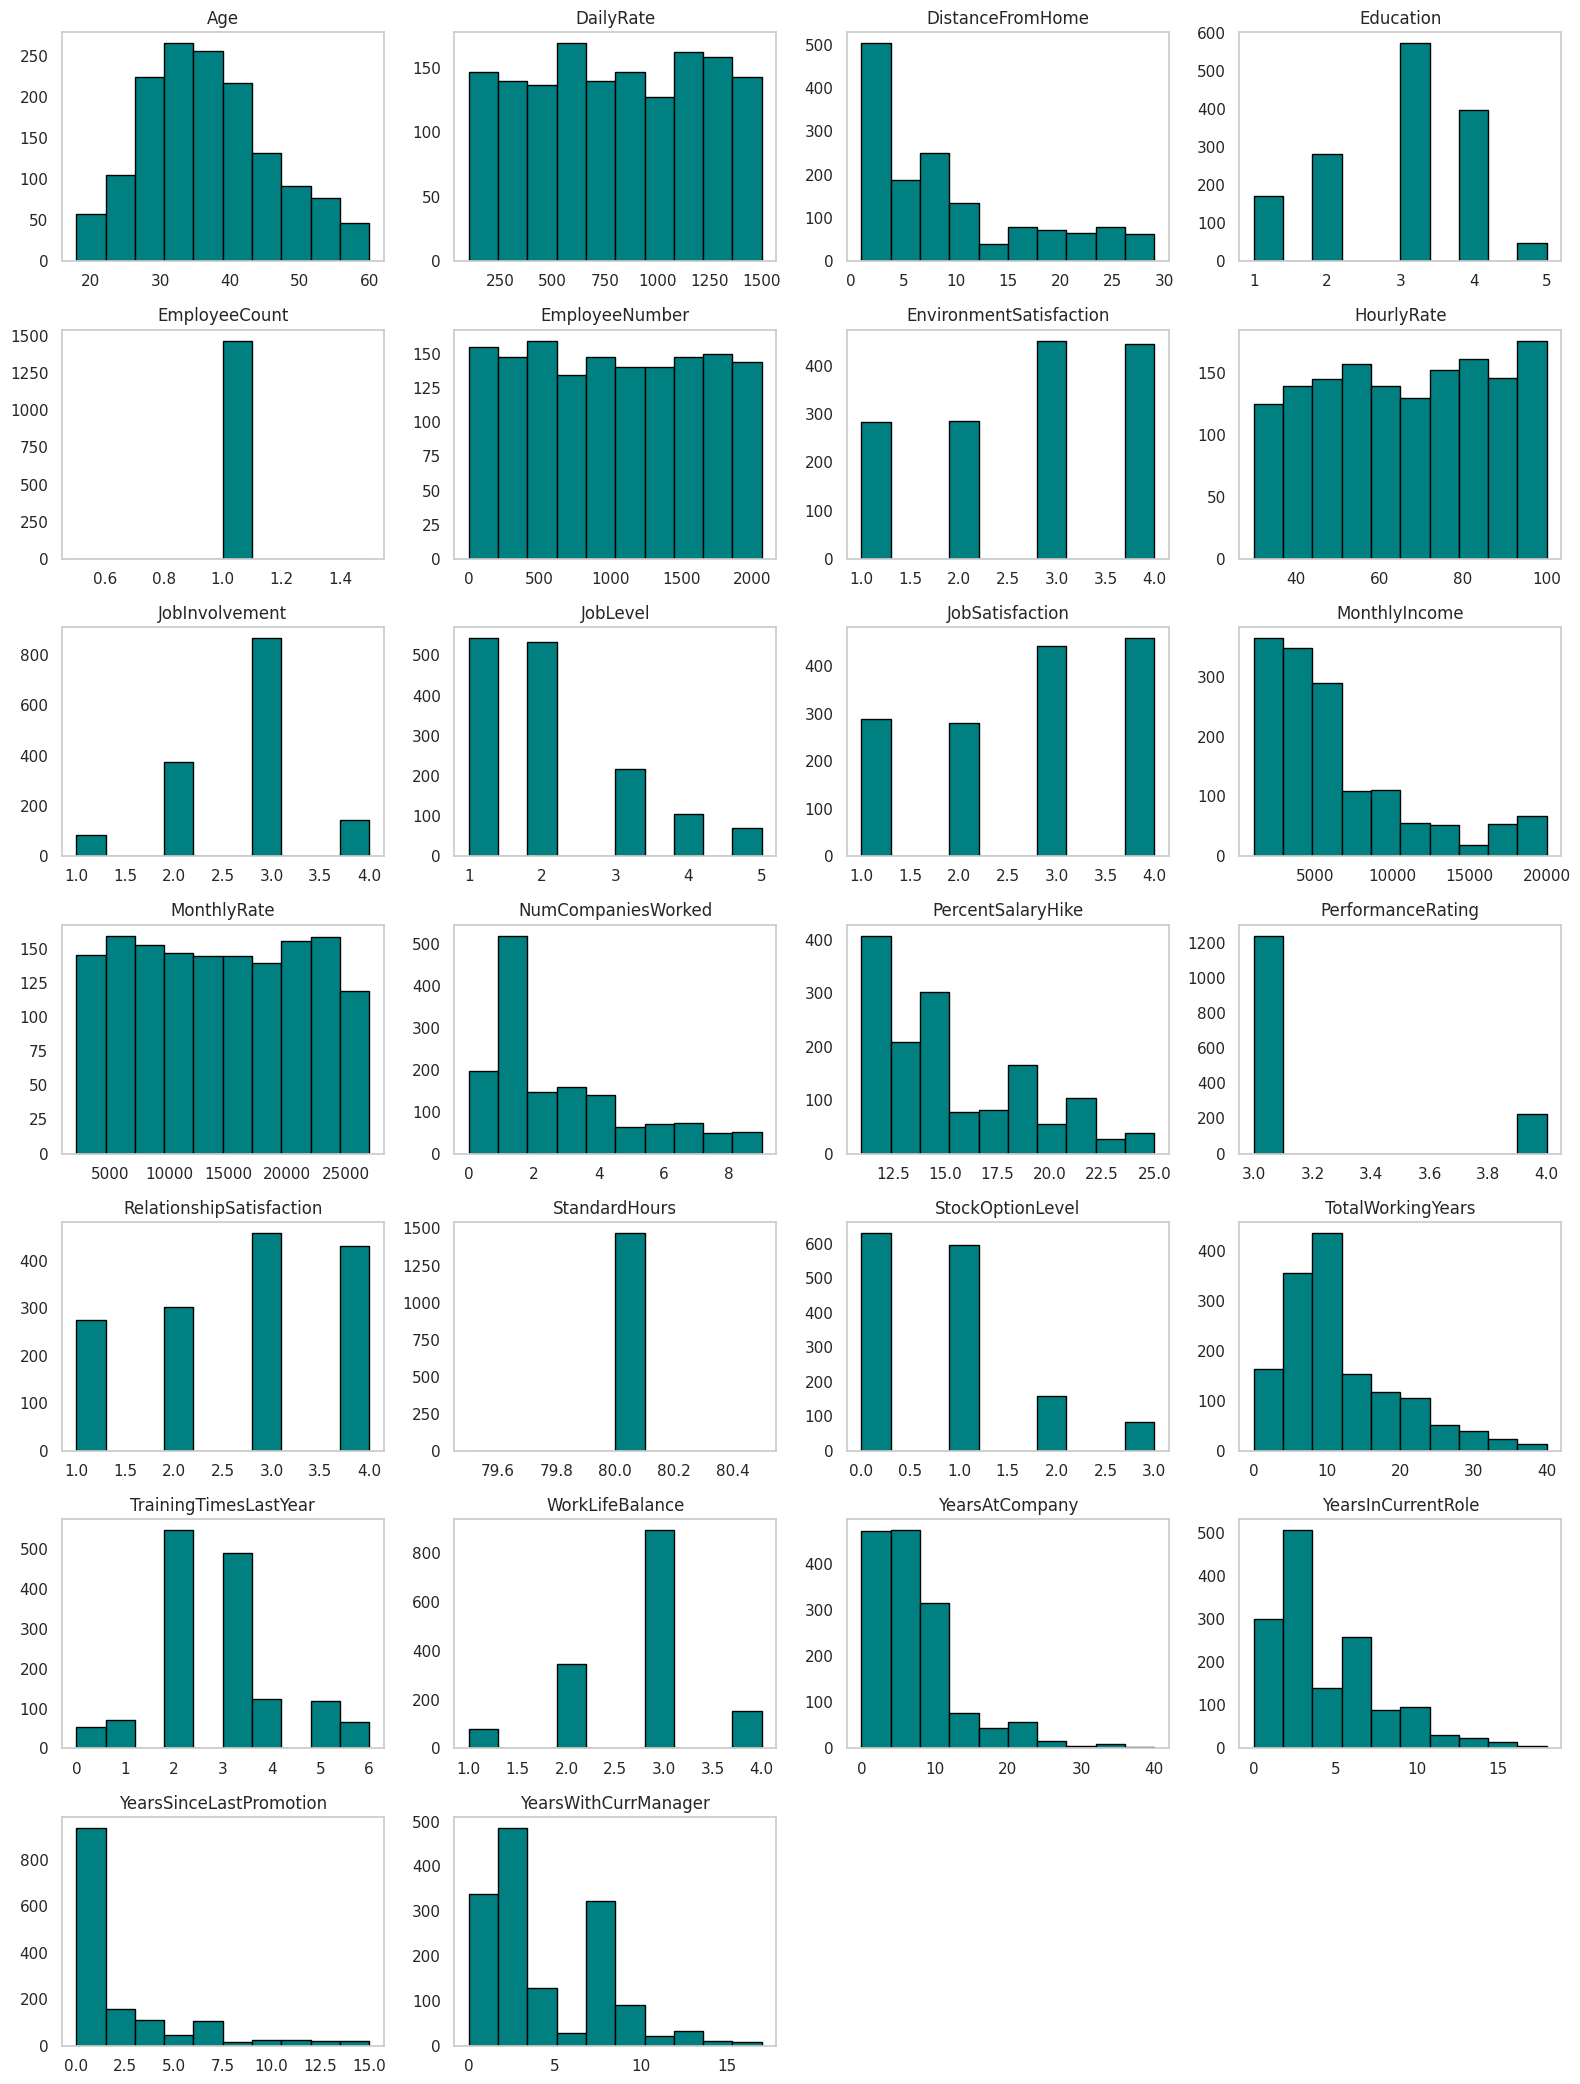

In [ ]:
# Visualización de columnas numéricas

# Calcular el número de filas necesarias dinámicamente
n_cols = 4
n_rows = (len(num_cols) + n_cols - 1) // n_cols

# Graficar todos los histogramas con diseño de 4 columnas
df[num_cols].hist(
    bins=10,
    layout=(n_rows, n_cols),
    figsize=(16, 3 * n_rows),
    color='teal',
    edgecolor='black',
    grid=False
)

# Ajustar el espacio entre los gráficos para que no se encimen las etiquetas
plt.tight_layout()
plt.show()

**Variables categóricas**

In [ ]:
# Imprimir información de columnas categóricas
for col in cat_cols:
    print(df[col].value_counts())
    print(f"Valores únicos: {df[col].nunique()}\n")

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Valores únicos: 2

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Valores únicos: 3

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
Valores únicos: 3

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64
Valores únicos: 6

Gender
Male      882
Female    588
Name: count, dtype: int64
Valores únicos: 2

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64
Valores únicos: 9

Mar

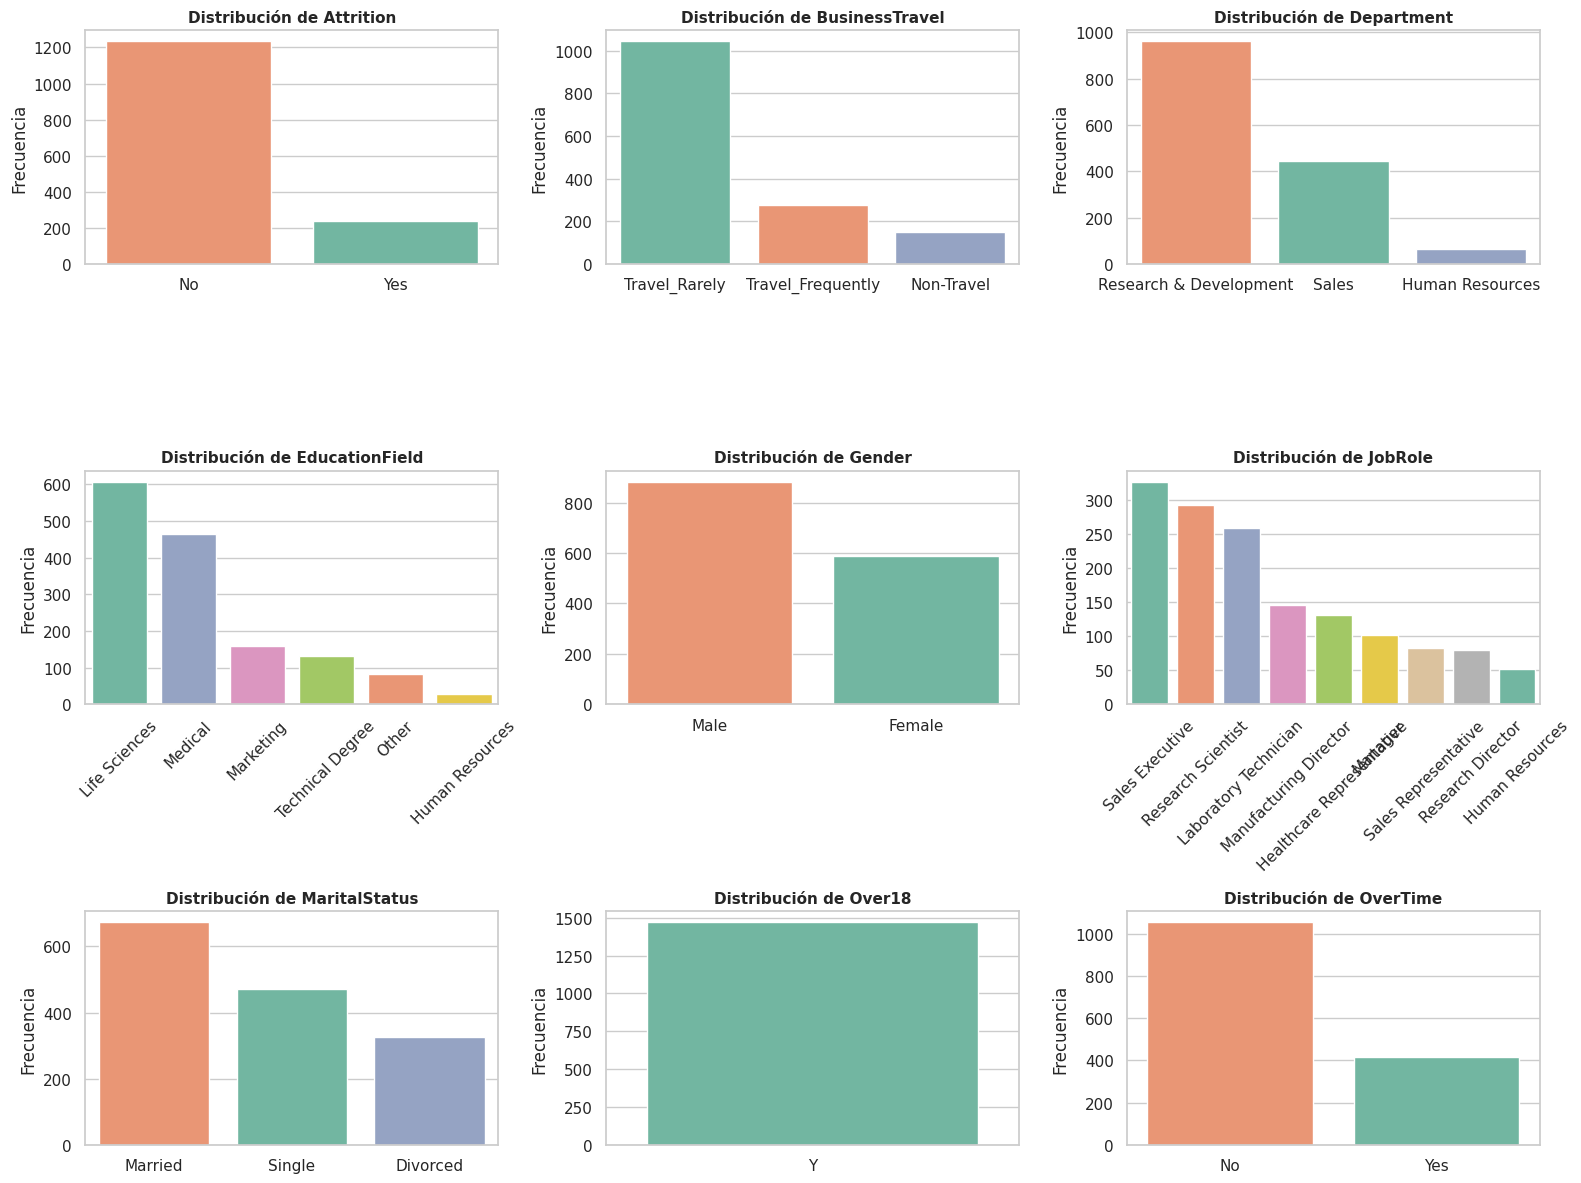

In [ ]:
# Visualización de columnas categóricas

# Calcular el número de filas necesarias para acomodar las variables (3 por fila)
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

# Crear la figura base con subplots dinámicos
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

# Graficar cada variable categórica en su respectivo subplot
for i, col in enumerate(cat_cols):
    # Ordenar las barras de mayor a menor frecuencia para mejorar la lectura gráfica
    order = df[col].value_counts().index

    sns.countplot(
        data=df,
        x=col,
        hue=col,
        order=order,
        palette='Set2',
        ax=axes[i],
        legend=False
    )

    axes[i].set_title(f'Distribución de {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

    # Rotar etiquetas si la variable tiene nombres largos para evitar solapamiento
    if df[col].nunique() > 3:
        axes[i].tick_params(axis='x', rotation=45)

# Ocultar los ejes que queden vacíos al final de la cuadrícula
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espacio entre los gráficos para que no se encimen las etiquetas
plt.tight_layout()
plt.show()

**Variable objetivo / Target**

In [ ]:
# Análisis del Target y Desbalanceo
target_counts = df['Attrition'].value_counts()
target_pct = df['Attrition'].value_counts(normalize=True) * 100
print(f"Desbalanceo de la Variable Objetivo ('Attrition'):")
for idx in target_counts.index:
    print(f"  - Clase '{idx}': {target_counts[idx]} empleados ({target_pct[idx]:.2f}%)")

Desbalanceo de la Variable Objetivo ('Attrition'):
  - Clase 'No': 1233 empleados (83.88%)
  - Clase 'Yes': 237 empleados (16.12%)


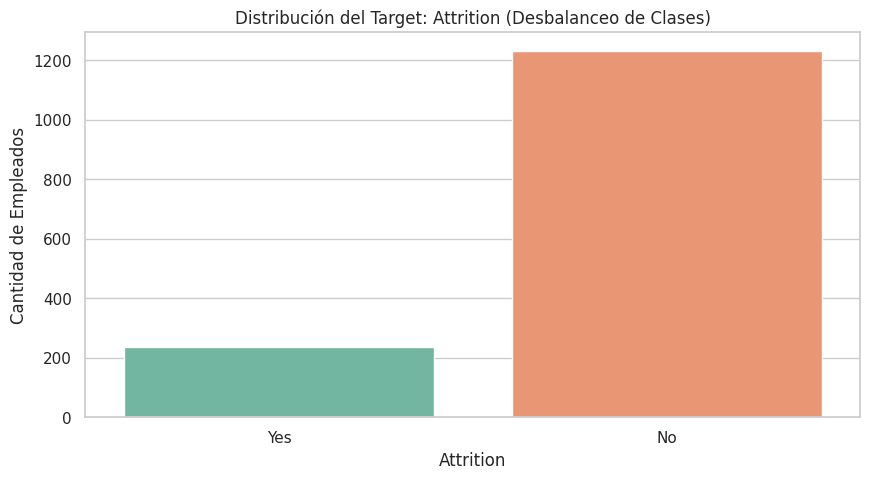

In [ ]:
# Gráfico: Distribución del Target
plt.figure()
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='Set2', legend=False)
plt.title('Distribución del Target: Attrition (Desbalanceo de Clases)')
plt.ylabel('Cantidad de Empleados')
plt.show()

**Estudio de Correlaciones**

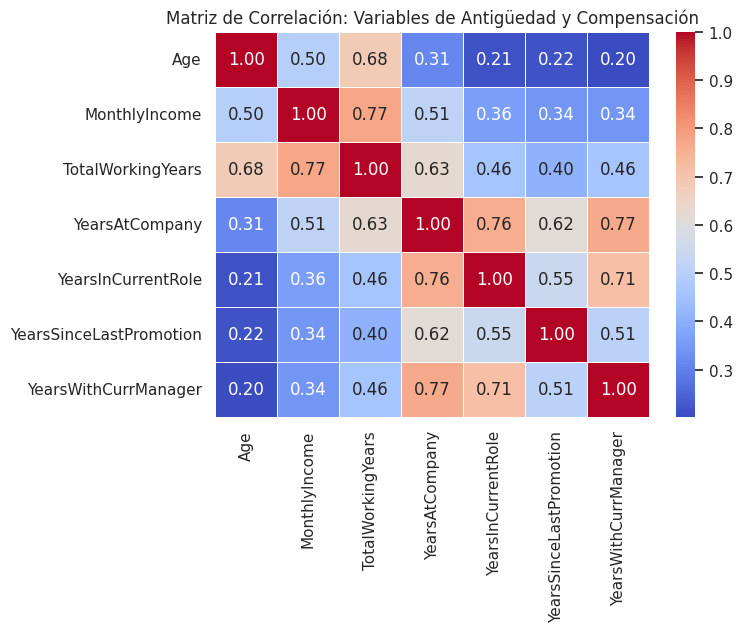

In [ ]:
# Estudio de Correlaciones y Multicolinealidad
# Matriz de Pearson para variables clave de antigüedad e ingresos
key_metrics = ['Age',
 'MonthlyIncome',
 'TotalWorkingYears',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

corr_matrix = df[key_metrics].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Variables de Antigüedad y Compensación')
plt.show()

## Preparación de los datos

In [ ]:
# Determinamos columnas numéricas y categóricas
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

print(f"Columnas numéricas: {len(numeric_cols)}")
print(f"Columnas categóricas: {len(categorical_cols)}")

Columnas numéricas: 26
Columnas categóricas: 9


**Feature selection**

Identificar y eliminar variables que no aporten información.

In [ ]:
# Identificar columnas constantes

# Para variables numéricas: Varianza igual a cero
constantes_num = [col for col in numeric_cols if df[col].var() == 0]

# Para variables categóricas: Solo tienen un valor único
constantes_cat = [col for col in categorical_cols if df[col].nunique() == 1]

columnas_constantes = constantes_num + constantes_cat
print(f"Columnas constantes: {columnas_constantes}")

Columnas constantes: ['EmployeeCount', 'StandardHours', 'Over18']


In [ ]:
# Identificar columnas con potencial de ser ID
columnas_id = [col for col in numeric_cols if df[col].nunique() == len(df)]
print(f"Columnas con potencial de ser ID: {columnas_id}")

Columnas con potencial de ser ID: ['EmployeeNumber']


In [ ]:
# Limpieza básica (columnas que no aporten información)
df = df.drop(columns = columnas_constantes + columnas_id, errors='ignore')

In [ ]:
# Código para eliminar columnas numéricas
numeric_cols = numeric_cols.drop(constantes_num + columnas_id)

In [ ]:
# Código para eliminar columnas categóricas
categorical_cols = categorical_cols.drop(constantes_cat)

* `StandardHours` y `EmployeeCount`: Tienen varianza cero. Esto significa que todos los registros del dataset tienen exactamente el mismo valor (80 y 1 respectivamente). Al ser una constante, carece de valor informativo.
* `Over18`: En este dataset el 100% de los empleados son mayores de 18 años (el valor es siempre 'Y'). Al ser una constante, carece de valor informativo.
* `EmployeeNumber`: Es un identificador único (ID). Funciona como una clave primaria; no tiene poder predictivo y solo genera ruido o sobreajuste en modelos basados en árboles.

In [ ]:
print(f"Columnas numéricas: {len(numeric_cols)}")
print(f"Columnas categóricas: {len(categorical_cols)}")

Columnas numéricas: 23
Columnas categóricas: 8


**Feature engineering**

Convertir variables binarias a numéricas

In [ ]:
# Identificar columnas binarias
columnas_binarias = [col for col in categorical_cols if df[col].nunique() == 2]
print(f"Columnas binarias: {columnas_binarias}")

Columnas binarias: ['Attrition', 'Gender', 'OverTime']


In [ ]:
# Imprimir información de columnas binarias
for col in columnas_binarias:
    print("\nFeature:", col)
    print(df[col].value_counts())


Feature: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Feature: Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

Feature: OverTime
OverTime
No     1054
Yes     416
Name: count, dtype: int64


In [ ]:
# Convertimos las binarias a numéricas
df['Attrition'] = df['Attrition'].map({'No': 0, 'Yes': 1}) # Binario: 1=Se va, 0=Se queda
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['OverTime'] = df['OverTime'].map({'No': 0, 'Yes': 1})

In [ ]:
# Código para añadir variables numericas
numeric_cols = pd.Index(numeric_cols.tolist() + columnas_binarias)

In [ ]:
# Código para eliminar variables categóricas
categorical_cols = categorical_cols.drop(columnas_binarias)

In [ ]:
print(f"Columnas numéricas: {len(numeric_cols)}")
print(f"Columnas categóricas: {len(categorical_cols)}")

Columnas numéricas: 26
Columnas categóricas: 5


Separar variables predictoras (features) de la variable respuesta (target)

In [ ]:
# Variable respuesta / Target
y = df['Attrition']

In [ ]:
# Explorando target
y.value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
# Variables predictoras / Features
X = df.drop(columns=["Attrition"])

In [ ]:
# Explorando Features
X.dtypes

,0
Age,int64
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EnvironmentSatisfaction,int64
Gender,int64
HourlyRate,int64


In [ ]:
# Determinamos features numéricos y categóricos

# Variables Numéricas Continuas + Ordinales (Van a StandardScaler)
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

# Variables Categóricas Nominales (No tienen un orden, van a One-Hot Encoding)
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

Numeric features: 25
Categorical features: 5


**Partición del Conjunto de Datos (Train/Test Split)**

In [ ]:
# División estratificada para mantener la proporción de la clase "Attrition"
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)

In [ ]:
print("Distribución original de clases:       ", np.bincount(y))
print("Distribución en train:                 ", np.bincount(y_train))
print("Distribución en test :                 ", np.bincount(y_test))
# Porcentajes
print("Distribución original de clases (pct): ", np.bincount(y)/sum(np.bincount(y))*100)
print("Distribución en train (pct):           ", np.bincount(y_train)/sum(np.bincount(y_train))*100)
print("Distribución en test (pct):            ", np.bincount(y_test)/sum(np.bincount(y_test))*100)

Distribución original de clases:        [1233  237]
Distribución en train:                  [986 190]
Distribución en test :                  [247  47]
Distribución original de clases (pct):  [83.87755102 16.12244898]
Distribución en train (pct):            [83.84353741 16.15646259]
Distribución en test (pct):             [84.01360544 15.98639456]


**Preprocesamiento**

OneHotEncoding para categóricas y Escalamiento para numéricas

In [ ]:
# Configuración del Transformador de Columnas
preprocess = ColumnTransformer(
    transformers=[
        # Aplica escalado a continuos y ordinales para Regresión Logística y MLP
        ("num", StandardScaler(), numeric_features),
        # Aplica One-Hot Encoding a las nominales, eliminando la primera columna para evitar multicolinealidad
        ("cat", OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# **Modelos Base y Regularización.**

**Modelos Base: Regresión Logística con Regularización (Lasso y Ridge)**

Como punto de partida (baseline), se seleccionaron dos variantes de Regresión Logística Regularizada: la variante Lasso, que incorpora una penalización $L_1$, y la variante Ridge, que añade una penalización $L_2$. Con el fin de sintonizar el balance óptimo entre el sesgo y la varianza, se implementó una búsqueda exhaustiva de hiperparámetros (GridSearchCV) orientada a optimizar la fuerza de regularización de ambas normas.

* Debido al desbalanceo nativo del problema, en ambos modelos se activó el parámetro
`class_weight='balanced'`, el cual modifica la función de pérdida asignando pesos inversamente
proporcionales a las frecuencias de las clases, forzando al optimizador a prestar mayor atención a la clase minoritaria (`Attrition = Yes`) en combinación con el efecto restrictivo de dichas penalizaciones.

**Metodología de Optimización y Selección de Métricas en Grid Search**

* Para ambas arquitecturas lineales, la cuadrícula de búsqueda (GridSearchCV ) evaluó el hiperparámetro de escala de regularización inversa `model__C` a través de nueve órdenes de magnitud: $C \in \{0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1.0, 10.0, 100.0\}$. Valores más bajos de C incrementan la fuerza de la regularización para combatir el sobreajuste (overfitting), mientras que valores altos permiten al modelo
ajustarse con mayor libertad a los datos de entrenamiento.

* Para la optimización de los hiperparámetros de los algoritmos, se implementó una estrategia de validación cruzada estratificada de 5 pliegues (5-fold Stratified K-Fold), asegurando la reproducibilidad mediante una semilla aleatoria fija (`random\_state=123`). El criterio de selección del mejor modelo dentro de la cuadrícula de búsqueda (GridSearchCV) requirió un análisis crítico debido al severo desbalanceo de clases identificado en la variable objetivo (Attrition: Yes $\approx$ 16\%, No $\approx$ 84\%).

* En este contexto, se descartó de forma categórica el uso de la métrica de exactitud global (Accuracy), dado que un clasificador ingenuo que prediga sistemáticamente la permanencia de todos los empleados alcanzaría un 84\% de aciertos sin aportar valor predictivo real.

* Por otro lado, al representar la media armónica entre la precisión (Precision) y la sensibilidad (Recall), optimizar el modelo bajo la métrica F1-score garantiza el balance óptimo para el negocio: maximizar la captura de empleados en riesgo real de deserción (evitando falsos negativos) sin saturar al departamento de Recursos Humanos con falsas alarmas que deriven en costos innecesarios de retención (mitigando falsos positivos).

* Por consiguiente, se determinó configurar el parámetro `scoring="f1"`enfocado exclusivamente en la clase positiva (`Attrition = Yes`).

## Regresión Logística con Regularización Lasso (L1)


In [ ]:
# Regresión Logística con Regularización
# Lasso (L1) - Selección intrínseca de variables

# Definir el modelo base con Lasso (L1) y balanceo de clases.
# Nota: Requiere el solver 'liblinear' o 'saga'
lr_lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    class_weight='balanced',
    random_state=123,
    max_iter=1000
)

# Crear el Pipeline.
# Primero transforma los datos y luego aplica el modelo
pipe_lasso = Pipeline([
    ('preprocess', preprocess),
    ('model', lr_lasso)
])

# Definir una cuadrícula de combinaciones de hiperparámetros.
# C: Fuerza de regularización
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1.0, 10.0, 100.0]
}

# Configurar la validación cruzada estratificada (mantiene la proporción de Attrition)
cv_folds = 5
cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=123)

# Configurar GridSearchCV buscando maximizar el score
# scoring: accuracy, balanced_accuracy, average_precision, f1, precision, recall
gs_lasso = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1
)

# Combinaciones totales
total_fits = len(ParameterGrid(param_grid)) * cv_folds

In [ ]:
# Ajustar el GridSearch usando los datos ORIGINALES (sin procesar previamente)
# El pipeline se encargará de hacer fit_transform internamente protegiendo la CV
with tqdm_joblib(tqdm(desc="Grid Search CV", total=total_fits)) as progress_bar:
    gs_lasso.fit(X_train, y_train)

Grid Search CV:   0%|          | 0/45 [00:00<?, ?it/s]

In [ ]:
# Extraer el mejor modelo y sus resultados desde el mejor pipeline
best_pipe_lasso = gs_lasso.best_estimator_

print("Mejores hiperparámetros:", gs_lasso.best_params_)
print(f"Mejor F1-score en CV: {gs_lasso.best_score_:.4f}\n")

# Evaluar el mejor modelo final con los datos de prueba (X_test)
# El pipeline automáticamente aplicará solo transform() a X_test usando los criterios de X_train
y_pred = best_pipe_lasso.predict(X_test)

print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Métricas detalladas (Enfocadas en detectar la Deserción: Clase 1) ===")
print(f"Precision (Clase 1): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Clase 1):    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score (Clase 1):  {f1_score(y_test, y_pred):.4f}")

print("\n=== Métricas Globales Robustas ===")
print(f"Balanced Accuracy:   {balanced_accuracy_score(y_test, y_pred):.4f}")

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

Mejores hiperparámetros: {'model__C': 0.5}
Mejor F1-score en CV: 0.5024

=== Matriz de Confusión ===
[[185  62]
 [ 12  35]]

=== Métricas detalladas (Enfocadas en detectar la Deserción: Clase 1) ===
Precision (Clase 1): 0.3608
Recall (Clase 1):    0.7447
F1-Score (Clase 1):  0.4861

=== Métricas Globales Robustas ===
Balanced Accuracy:   0.7468

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.94      0.75      0.83       247
           1       0.36      0.74      0.49        47

    accuracy                           0.75       294
   macro avg       0.65      0.75      0.66       294
weighted avg       0.85      0.75      0.78       294



Observamos que, el modelo identificó bien a 35 empleados de los 47 que realmente se fueron, pero tiene un alto costo de precisión, dado que clasificó a 62 empleados que en realidad se quedaron, como si se fueran a ir.

## Regresión Logística con Regularización Ridge (L2)

In [ ]:
# BASELINE: Regresión Logística con Regularización
# Ridge (L2) - Manejo de multicolinealidad

# Definir el modelo base con Ridge (L2) y balanceo de clases.
# Nota: Acepta el solver lbfgs (default), newton-cg, newton-cholesky, sag, liblinear
lr_ridge = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    random_state=123,
    max_iter=1000
)

# Crear el Pipeline.
# Primero transforma los datos y luego aplica el modelo
pipe_ridge = Pipeline([
    ('preprocess', preprocess),
    ('model', lr_ridge)
])

# Definir una cuadrícula de combinaciones de hiperparámetros.
# Al usar un Pipeline, debes anteponer el nombre del paso seguido de dos guiones bajos (__)
# C: Fuerza de regularización
param_grid = {
    'model__C': [0.001, 0.01, 0.1, 0.25, 0.5, 0.75, 1.0, 10.0, 100.0]
}

# Configurar la validación cruzada estratificada (mantiene la proporción de Attrition)
cv_folds = 5
cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=123)

# Configurar GridSearchCV buscando maximizar el score
# scoring: accuracy, balanced_accuracy, average_precision, f1, precision, recall
gs_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid,
    scoring="f1",
    cv=cv_strategy,
    n_jobs=-1
)

# Combinaciones totales
total_fits = len(ParameterGrid(param_grid)) * cv_folds

In [ ]:
# Ajustar el GridSearch usando los datos ORIGINALES (sin procesar previamente)
# El pipeline se encargará de hacer fit_transform internamente protegiendo la CV
with tqdm_joblib(tqdm(desc="Grid Search CV", total=total_fits)) as progress_bar:
    gs_ridge.fit(X_train, y_train)

Grid Search CV:   0%|          | 0/45 [00:00<?, ?it/s]

In [ ]:
# Extraer el mejor modelo y sus resultados desde el mejor pipeline
best_pipe_ridge = gs_ridge.best_estimator_

print("Mejores hiperparámetros:", gs_ridge.best_params_)
print(f"Mejor F1-score en CV: {gs_ridge.best_score_:.4f}\n")

# Evaluar el mejor modelo final con los datos de prueba (X_test)
# El pipeline automáticamente aplicará solo transform() a X_test usando los criterios de X_train
y_pred = best_pipe_ridge.predict(X_test)

print("=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Métricas detalladas (Enfocadas en detectar la Deserción: Clase 1) ===")
print(f"Precision (Clase 1): {precision_score(y_test, y_pred):.4f}")
print(f"Recall (Clase 1):    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score (Clase 1):  {f1_score(y_test, y_pred):.4f}")

print("\n=== Métricas Globales Robustas ===")
print(f"Balanced Accuracy:   {balanced_accuracy_score(y_test, y_pred):.4f}")

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

Mejores hiperparámetros: {'model__C': 0.25}
Mejor F1-score en CV: 0.5125

=== Matriz de Confusión ===
[[185  62]
 [ 12  35]]

=== Métricas detalladas (Enfocadas en detectar la Deserción: Clase 1) ===
Precision (Clase 1): 0.3608
Recall (Clase 1):    0.7447
F1-Score (Clase 1):  0.4861

=== Métricas Globales Robustas ===
Balanced Accuracy:   0.7468

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.94      0.75      0.83       247
           1       0.36      0.74      0.49        47

    accuracy                           0.75       294
   macro avg       0.65      0.75      0.66       294
weighted avg       0.85      0.75      0.78       294



Desde el punto de vista del negocio y los objetivos de Recursos Humanos, ambos modelos logran una sensibilidad (Recall) destacable del $74\%$, lo que significa que el sistema es capaz de detectar correctamente a $35$ de los $47$ empleados que realmente causarán baja en la empresa ($TP=35$, $FN=12$). No obstante, este rendimiento preventivo se penaliza con una precisión moderada del $36\%$, generando $62$ falsos positivos ($FP$). Esta cantidad de falsas alarmas establece un punto de partida que buscaremos reducir en las siguientes secciones del reporte, poniendo a prueba a modelos más avanzados y complejos como Random Forest, AdaBoost, XGBoost y el Perceptrón Multicapa (MLP).

## Interpretación de coeficientes

In [ ]:
# Extraer el preprocesador y nombres de columnas transformadas
preprocesador = best_pipe_lasso.named_steps['preprocess']
nombres_features = preprocesador.get_feature_names_out()

# Limpiar los prefijos 'num__' y 'cat__' para que el reporte se vea profesional
nombres_limpios = [name.split('__')[1] for name in nombres_features]

# Extraer los modelos optimizados desde el mejor pipeline de cada GridSearchCV
best_lasso = best_pipe_lasso.named_steps['model']
best_ridge = best_pipe_ridge.named_steps['model']

# Identificar coeficientes que Lasso llevó a cero (variables descartadas)
# Creamos el diccionario (usamos [0] porque coef_ es una matriz bidimensional)
coef_lasso = dict(zip(nombres_limpios, best_lasso.coef_[0]))

# Identificar las variables que Lasso eliminó (coeficiente igual a cero)
variables_eliminadas = [col for col, coef in coef_lasso.items() if coef == 0]

# Crear el DataFrame consolidado de coeficientes (usamos .flatten() para asegurar 1D)
df_coef = pd.DataFrame({
    'Variable': nombres_limpios,
    'Coef_Lasso (L1)': best_lasso.coef_.flatten(),
    'Coef_Ridge (L2)': best_ridge.coef_.flatten()
})

# Redondear a 4 decimales
df_coef[['Coef_Lasso (L1)', 'Coef_Ridge (L2)']] = df_coef[['Coef_Lasso (L1)', 'Coef_Ridge (L2)']].round(4)

In [ ]:
print("=== RESULTADO DE SELECCIÓN INTRÍNSECA (LASSO) ===")
print(f"Total de variables transformadas: {len(nombres_limpios)}")
print(f"Variables eliminadas por el modelo ({len(variables_eliminadas)}):", variables_eliminadas)

=== RESULTADO DE SELECCIÓN INTRÍNSECA (LASSO) ===
Total de variables transformadas: 44
Variables eliminadas por el modelo (8): ['HourlyRate', 'Department_Sales', 'EducationField_Marketing', 'EducationField_Other', 'JobRole_Human Resources', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive']


Selección de Características en Lasso ($L_1$):

La optimización seleccionó un valor óptimo de $C = 0.50$ a través de la validación cruzada. Desde la perspectiva analítica, esta regularización cumplió de forma efectiva su función de simplificación estructural sobre el espacio expandido de 44 variables transformadas, logrando reducir a cero los coeficientes de 8 atributos redundantes o irrelevantes (tales como
'HourlyRate', 'Department_Sales', 'EducationField_Marketing', 'EducationField_Other', 'JobRole_Human Resources', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive').


In [ ]:
# Mostrar ordenado por el impacto absoluto en Lasso
print("=== COEFICIENTES OPTIMIZADOS ===")
print(df_coef.sort_values(by='Coef_Lasso (L1)', key=abs, ascending=False).to_string(index=False))

=== COEFICIENTES OPTIMIZADOS ===
                         Variable  Coef_Lasso (L1)  Coef_Ridge (L2)
 BusinessTravel_Travel_Frequently           1.0136           0.9544
             MaritalStatus_Single           0.9260           0.9177
Department_Research & Development          -0.8429          -0.2974
    JobRole_Laboratory Technician           0.7984           0.6653
                         OverTime           0.7241           0.7278
  EducationField_Technical Degree           0.7039           0.5459
     BusinessTravel_Travel_Rarely           0.5922           0.5780
     JobRole_Sales Representative           0.5837           0.6556
          YearsSinceLastPromotion           0.5517           0.5462
               YearsInCurrentRole          -0.5061          -0.5200
             YearsWithCurrManager          -0.4808          -0.4987
   JobRole_Manufacturing Director           0.4649           0.4181
                   YearsAtCompany           0.4635           0.5087
               

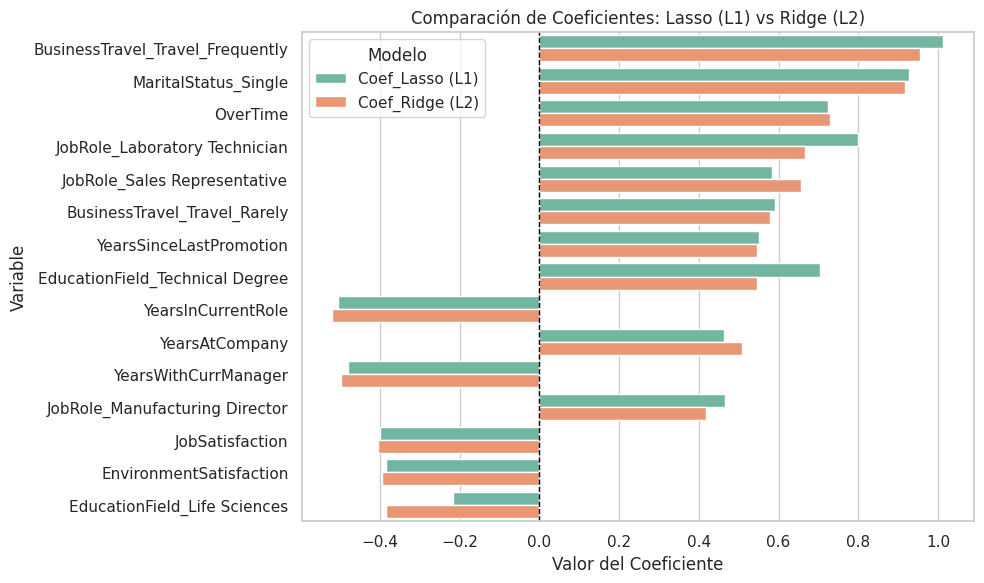

In [ ]:
# Filtrar las 15 variables con mayor impacto en Ridge para no saturar la gráfica
df_plot = df_coef.sort_values(by='Coef_Ridge (L2)', key=abs, ascending=False).head(15)

# Convertir a formato largo (long format) para seaborn
df_melted = df_plot.melt(id_vars='Variable', var_name='Modelo', value_name='Valor del Coeficiente')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, y='Variable', x='Valor del Coeficiente', hue='Modelo', palette='Set2')
plt.title('Comparación de Coeficientes: Lasso (L1) vs Ridge (L2)')
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

# **Modelos de Ensamble y Redes.**

### Random Forest

Para tunear los hiperparámetros de `RandomForestClassifier` se utilizó `GridSearchCV`. El mejor conjunto de hiperparámetros se decide a través de un puntaje, el cual se pasa al parámetro `scoring` de `GridSearchCV`. De manera predeterminada, este puntaje es *accuracy* (`"accuracy"`); sin embargo, como las clases no están balanceadas, se obtuvieron mejores resultados con puntajes como F1 (`"f1"`) *weighted* F1 (`"f1_weighted"`) y *weighted recall* (`"recall_weighted"`). Se hizo pruebas con *recall* (`"recall"`), pero el algoritmo arrojaba conjuntos de parámetros de bosques que clasificaba como `1` a casi todas las observaciones del conjunto de prueba, pues, en efecto, los bosques entrenados con estos parámetros obtendrían valores de *recall* cercanos a 1 en cada iteración del *grid search*.

También se realizaron pruebas utilizando como puntajes el área bajo la curva ROC (`"roc_auc"`) y el coeficiente de correlación de Matthews (CCM). Para este último puntaje debía pasarse al argumento `scoring` la función `make_scorer()` de `sklearn.metrics`, evaluada en `matthews_corrcoef` del mismo módulo, es decir,

```python
score=make_scorer(matthews_corrcoef)
```

Aunque ambos puntajes son más adecuadas para medir el desempeño de modelos de clasificación con datos desbalanceados, los modelos obtenidos con estos puntajes eran generalmente peores que los obtenidos con F1, *weighted* F1 y *weighted recall*. Aun así, algunos modelos obtenidos con el CCM eran un poco mejores en algunos aspectos.

También hicimos pruebas pasando métricas definidas por nosotros a la función `make_scorer()`. Con una de estas métrica se obtuvieron buenos valores de *accuracy* y *precision*, pero pobres de *recall*. Veamos cómo definimos el puntaje. Sean $TP$, $FN$ y $FP$ el número de positivos verdaderos, falsos negativos y falsos positivos respectivamente obtenidos en una iteración del *grid search*. El puntaje se calcula como
$$
\frac{TP}{FN + 6\cdot FP}
$$
Entre mayor fuera el número de positivos clasificados correctamente y menor fueran el número de datos clasificados incorrectamente, tanto falsos positivos como falsos negativos, el puntaje aumentaría. Notemos que $FP$ se multiplica por $6$ para penalizar todavía más los falsos positivos, con lo que mejoramos *precision*. Además, como el número de negativos es mucho mayor, tener menos falsos positivos mejora de manera general el *accuracy*. Notemos que con esta métrica el *recall* no mejora casi nada; aun así, los resultados no fueron los peores obtenidos.

El algoritmo de árbol aleatorio le da el mismo peso de 1 a cada clase a la hora de dividir cada nodo, lo que ocasiona que los valores de *recall* y *precision* no sean buenos con el conjunto de prueba. Es por esto que debemos utilizar el parámetro `class_weight` de `RandomForestClassifier`, al cual se le pueden asignar los argumentos `"balanced"`, `"balanced_subsample"` o diccionarios en los que se asigna a cada categoría un peso, por ejemplo `{0: 1, 1: 8}`. Al utilizar `"balanced"`, a cada categoría de la variable objetivo se le asigna un peso inversamente proporcional a su frecuencia. A continuación se explica cómo se calcula. Sea $N$ el número de observaciones en el conjunto utilizado para entrenar el bosque aleatorio, $c$ el número de clases y $n_i$ el número de observaciones de la clase $i$. A cada clase $i$ se la asigna el siguiente peso:
$$
\frac{N}{c \cdot n_i}
$$
La estrategia de validación cruzada que utilizamos en el *grid search*, `StratifiedKFold`, hace que en cada iteración haya una proporción de clases muy similar a la proporción del conjunto de entrenamiento completo `y_train`. Así mismo, `y_train` conserva la proporción de clases de `y`, el vector de observaciones completo, debido a que se utilizó el parámetro `stratify` con argumento `y` de la función `train_test_split()`. De este modo, el peso asignado a cada clase en cada iteración del *grid search* es similar a la que se le asignaría a cada clase si entrenáramos el bosque con `y`. Así pues, el peso de la clase `0` sería aproximadamente
$$
\frac{1470}{2 \cdot 1233} \approx 0.5961
$$
y la de la clase `1`,
$$
\frac{1470}{2 \cdot 237} \approx 3.1013
$$
Con el argumento `"balanced_subsample"`, los pesos de cada clase se calculan individualmente para cada árbol, utilizando para ello el conjunto bootstrap que le tocó a cada uno.

También hicimos pruebas asignando manualmente un peso a cada clase, pasando al argumento `class_weight` diccionarios como `{0: 1, 1: 6}`, `{0: 1, 1: 7}`, `{0: 1, 1: 8}` para darle todavía más peso a la clase minoritaria que la que se le da al pasar los argumentos `"balanced"` y `"balanced_subsample"`. En la mayoría de los casos se obtenían mejores resultados con `"balanced"` y `{0: 1, 1: 8}`.

Para limitar el tamaño de los árboles podemos utilizar los parámetros `max_depth` o `min_samples_leaf`. Al primer parámetro se le puede asignar un entero que determina la profundidad máxima de cada árbol; al segundo se le puede asignar un entero que determina el número mínimo de instancias que debe haber en cada hoja, o bien, un flotante mayor a `0.0` y menor o igual a `1.0`, que representa el porcentaje mínimo de instancias que debe haber en cada hoja. Decidimos tunear el parámetro `min_samples_leaf` pasándole porcentajes en vez de `max_depth`. En general se obtenían mejores resultados con árboles más profundos.

Para agregar aleatoriedad a cada árbol y hacerlos más independientes entre sí, también utilizamos el parámetro `max_features` para que cada uno de estos se entrenara con un subconjunto aleatorio de todas las *features*. Este puede ser un entero, que representa el número de features, seleccionadas aleatoriamente, con el que se entrena cada árbol o un porcentaje de todas las *features*. Se decidió tunear este hiperparámetro con el porcentaje, el cual puede ser cualquier valor mayor a `0.0` y menor o igual a `1.0`. Los porcentajes que arrojaban los mejores resultados variaban más.

Como criterio (parámetro `criterion`) de división de los nodos utilizamos el predeterminado de impureza de Gini (`"gini"`). Para el resto de parámetros también se utilizaron sus valores predeterminados.

Vamos a ver ejemplos de algunos árboles obtenidos con los distintos puntajes de `GridSearchCV`.

Primero cargamos las librerías.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, ParameterGrid
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, make_scorer, matthews_corrcoef

Función para imprimir el desempeño del mejor bosque obtenido con el *grid search*.

In [ ]:
def resumen_clasificacion_gridcv(gridcv, X_test, y_test):
    print("Mejores parámetros:\n", gridcv.best_params_)
    print("=========================================================")
    print(f"Mejor Score: {gridcv.best_score_:.4f}")

    y_pred = gridcv.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

    print("=========================================================")
    print("Matriz de confusión:")
    print(cm)
    print("=========================================================")
    print("Mal clasificados:", cm[1, 0] + cm[0, 1])
    print("=========================================================")
    print("Reporte de clasificación:")
    print(classification_report(y_true=y_test, y_pred=y_pred))

No es necesario realizar una estandarización de los datos para entrenar un bosque aleatorio, así que desde el principio se crean las dummies de las variables categóricas y se hace la división entre datos de entrenamiento y de prueba.

In [ ]:
X_forest = pd.get_dummies(X, columns=X.select_dtypes("object").columns, drop_first=True)

In [ ]:
len(X_forest.columns)

44

Realizamos una división estratificada para mantener la proporción de las clases de la variable objetivo.

In [ ]:
X_train_forest, X_test_forest, y_train_forest, y_test_forest = train_test_split(
    X_forest, y, test_size=0.20, random_state=123, stratify=y
)

El tuneo de hiperparámetros fue más exhaustivo, pero aquí se presenta una malla más pequeña para que el código no tarde mucho en ejecutarse durante esta presentación. En este caso utilizamos *weighted* F1 como puntaje y un peso de 1 para la clase 0 y de 8 para la clase 1. La malla original fue la siguiente:

```python
parametros_malla = {
    "max_features": np.linspace(0.45, 0.6, 5),
    "min_samples_leaf": np.linspace(0.001, 0.05, 5),
}
```

In [ ]:
# Definir una malla de combinaciones de hiperparámetros
parametros_malla = {
    "max_features": [0.4875, 0.525],
    "min_samples_leaf": [0.001, 0.01325],
}

# Configurar la validación cruzada estratificada (mantiene la proporción de Attrition)
cv_folds = 5
cv_estrategia = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

# Configurar GridSearchCV buscando maximizar el score
gridcv_mejor_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=1000, class_weight={0: 1, 1: 8}, random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring="f1_weighted",
    n_jobs=-1,
)

# Combinaciones totales
total_fits = len(ParameterGrid(parametros_malla)) * cv_folds

Ajustamos el GridSearch usando los datos ORIGINALES (sin procesar previamente):

In [ ]:
with tqdm_joblib(tqdm(desc="Grid Search CV", total=total_fits)) as progress_bar:
    gridcv_mejor_forest.fit(X_train_forest, y_train_forest)

Grid Search CV:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
resumen_clasificacion_gridcv(
    gridcv_mejor_forest, X_test=X_test_forest, y_test=y_test_forest
)

Mejores parámetros:
 {'max_features': 0.4875, 'min_samples_leaf': 0.01325}
Mejor Score: 0.8139
Matriz de confusión:
[[203  44]
 [ 11  36]]
Mal clasificados: 55
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88       247
           1       0.45      0.77      0.57        47

    accuracy                           0.81       294
   macro avg       0.70      0.79      0.72       294
weighted avg       0.87      0.81      0.83       294



Con el conjunto de prueba obtenemos un *recall* de 0.77 y una *precision* de 0.45. Se obtiene un *accuracy* de 0.81, que no es muy bueno considerando que la clase mayoritaria representa el 83.9% de la variable objetivo. El porcentaje de *features* con que se entrena cada árbol es de 48.75%, por lo que cada árbol se entrena con 21 de las 44 *features*. Por otra parte, dado que el mejor valor de `min_samples_leaf` es 0.01325 y `X_train_forest` tiene 1176 instancias, los árboles de este bosque deben tener como mínimo 16 observaciones en sus hojas; por tanto, los árboles de este bosque son profundos. Las pruebas iniciales fueron con árboles menos profundos, pero el desempeño no era muy bueno.

Guardamos las métricas de este bosque aleatorio para compararlas con las de los demás modelos más adelante.

In [ ]:
y_pred_forest = gridcv_mejor_forest.predict(X_test_forest)

metricas_forest = [
    precision_score(y_test_forest, y_pred_forest),
    recall_score(y_test_forest, y_pred_forest),
    f1_score(y_test_forest, y_pred_forest)
]

El siguiente también es un bosque obtenido con el puntaje de *weighted* F1. La malla original fue

```python
parametros_malla = {
    "max_features": np.linspace(0.1, 0.25, 10),
    "min_samples_leaf": np.linspace(0.001, 0.005, 10),
}
```

No se utilizaron mallas más grandes por *grid search* para no derretir el CPU de mi laptop. Notemos que en este caso se utilizó un conjunto de `max_features` con valores más pequeños que en el anterior.

En el resto de modelos, se utiliza `"balanced"` como `class_weight`.

In [ ]:
parametros_malla = {
    "max_features": [0.16666667],
    "min_samples_leaf": [0.004555555555555556],
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)
bosque_cv = RandomForestClassifier(n_estimators=700, class_weight="balanced", random_state=42)

gridcv_forest = GridSearchCV(
    bosque_cv,
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring="f1_weighted",
    n_jobs=-1,
)

gridcv_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_forest, X_test=X_test_forest, y_test=y_test_forest)

Mejores parámetros:
 {'max_features': 0.16666667, 'min_samples_leaf': 0.004555555555555556}
Mejor Score: 0.8405
Matriz de confusión:
[[235  12]
 [ 25  22]]
Mal clasificados: 37
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      0.95      0.93       247
           1       0.65      0.47      0.54        47

    accuracy                           0.87       294
   macro avg       0.78      0.71      0.74       294
weighted avg       0.86      0.87      0.87       294



La profundidad de los árboles de este bosque es todavía mayor. El *accuracy* mejoró, pero la clasificación correcta de la clase minoritaria disminuyó. No obstante, notemos que el puntaje obtenido fue de 0.8405, mejor que el de 0.8139 del árbol anterior. Por tanto, en un escenario en el que no tuviéramos acceso al conjunto de prueba, el modelo final que utilizaríamos sería este último, a pesar de que su desempeño con la clase minoritaria es peor.

Veamos dos *grid search* que obtuvieron el mejor conjunto de parámetros a partir de dos mallas diferentes, pero utilizando como puntaje `"recall_weighted"`. Las mallas originales respectivas son las siguientes:

```python
parametros_malla = {
    "max_features": np.linspace(0.3, 0.5, 10),
    "min_samples_leaf": np.linspace(0.001, 0.01, 5),
}
```

```python
parametros_malla = {
    "max_features": np.linspace(0.2, 0.3, 10),
    "min_samples_leaf": np.linspace(0.001, 0.005, 10),
}
```

In [ ]:
parametros_malla = {
    "max_features": [0.3],
    "min_samples_leaf": [0.00325],
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)

gridcv_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring="recall_weighted",
    n_jobs=-1,
)

gridcv_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_forest, X_test_forest, y_test_forest)

Mejores parámetros:
 {'max_features': 0.3, 'min_samples_leaf': 0.00325}
Mejor Score: 0.8563
Matriz de confusión:
[[240   7]
 [ 27  20]]
Mal clasificados: 34
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       247
           1       0.74      0.43      0.54        47

    accuracy                           0.88       294
   macro avg       0.82      0.70      0.74       294
weighted avg       0.87      0.88      0.87       294



In [ ]:
parametros_malla = {
    "max_features": [0.2111111111111111],
    "min_samples_leaf": [0.0032222222222222222],
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)

gridcv_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring="recall_weighted",
    n_jobs=-1,
)

gridcv_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_forest, X_test_forest, y_test_forest)

Mejores parámetros:
 {'max_features': 0.2111111111111111, 'min_samples_leaf': 0.0032222222222222222}
Mejor Score: 0.8572
Matriz de confusión:
[[238   9]
 [ 28  19]]
Mal clasificados: 37
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       247
           1       0.68      0.40      0.51        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.72       294
weighted avg       0.86      0.87      0.86       294



De nuevo, nos quedaríamos con el segundo modelo, a pesar del mejor desempeño del primero. Aun así, notemos que el F1 es mejor en ambos que los obtenidos con el puntaje *weighted F1*, debido a que *precision* aumentó, aunque *recall* empeoró.

Veamos dos *grid search*  utilizando como puntaje `"roc_auc"`, que es en teoría mejor para clases desbalanceadas. Las mallas originales son las siguientes:

```python
parametros_malla = {
    "max_features": np.linspace(0.1, 0.5, 20),
    "min_samples_leaf": np.linspace(0.001, 0.2, 20),
}
```

```python
parametros_malla = {
    "max_features": np.linspace(0.01, 0.3, 25),
    "min_samples_leaf": np.linspace(0.0001, 0.01, 20),
}
```

In [ ]:
parametros_malla = {
    "max_features": [0.1],
    "min_samples_leaf": [0.001],
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)

gridcv_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring="roc_auc",
    n_jobs=-1,
)

gridcv_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_forest, X_test_forest, y_test_forest)

Mejores parámetros:
 {'max_features': 0.1, 'min_samples_leaf': 0.001}
Mejor Score: 0.7981
Matriz de confusión:
[[245   2]
 [ 35  12]]
Mal clasificados: 37
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       247
           1       0.86      0.26      0.39        47

    accuracy                           0.87       294
   macro avg       0.87      0.62      0.66       294
weighted avg       0.87      0.87      0.84       294



In [ ]:
parametros_malla = {
    "max_features": [0.11875],
    "min_samples_leaf": [0.0011421052631578948],
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)

gridcv_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring="roc_auc",
    n_jobs=-1,
)

gridcv_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_forest, X_test_forest, y_test_forest)

Mejores parámetros:
 {'max_features': 0.11875, 'min_samples_leaf': 0.0011421052631578948}
Mejor Score: 0.8014
Matriz de confusión:
[[243   4]
 [ 38   9]]
Mal clasificados: 42
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       247
           1       0.69      0.19      0.30        47

    accuracy                           0.86       294
   macro avg       0.78      0.59      0.61       294
weighted avg       0.84      0.86      0.82       294



De nuevo, en un escenario sin acceso al conjunto de prueba, nos quedaríamos con el segundo modelo a pesar de su peor desempeño. No obstante, el desempeño de ambos es peor que los obtenidos con *weighted recall* y *weighted* F1. El *recall* obtenido con el conjunto de prueba es muy malo y el *accuracy* no mejora. Lo que sí mejora respecto a los modelos anteriores es el *recall* de la clase 0 (0.99 y 0.98), pero el desempeño de la clase mayoritaria no es de interés en este problema.

Veamos qué ocurre al utilizar como puntaje el coeficiente de correlación de Matthews. Las mallas originales fueron las siguientes:

```python
parametros_malla = {
    "max_features": np.linspace(0.1, 0.5, 10),
    "min_samples_leaf": np.linspace(0.001, 0.01, 10),
}
```

```python
parametros_malla = {
    "max_features": np.linspace(0.1, 0.3, 20),
    "min_samples_leaf": np.linspace(0.001, 0.02, 20),
}
```

In [ ]:
parametros_malla = {
    "max_features": [0.2777777777777778],
    "min_samples_leaf": [0.008],
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)

gridcv_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    # Como matthews_corrcoef no está implementada, debe hacerse un scorer
    # a partir de ella con make_scorer()
    scoring=make_scorer(matthews_corrcoef),
    n_jobs=-1,
)

gridcv_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_forest, X_test_forest, y_test_forest)

Mejores parámetros:
 {'max_features': 0.2777777777777778, 'min_samples_leaf': 0.008}
Mejor Score: 0.3974
Matriz de confusión:
[[224  23]
 [ 23  24]]
Mal clasificados: 46
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       247
           1       0.51      0.51      0.51        47

    accuracy                           0.84       294
   macro avg       0.71      0.71      0.71       294
weighted avg       0.84      0.84      0.84       294



In [ ]:
parametros_malla = {
    "max_features": [0.2578947368421053],
    "min_samples_leaf": [0.012],
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)

gridcv_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=500, class_weight="balanced", random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring=make_scorer(matthews_corrcoef),
    n_jobs=-1,
)

gridcv_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_forest, X_test_forest, y_test_forest)

Mejores parámetros:
 {'max_features': 0.2578947368421053, 'min_samples_leaf': 0.012}
Mejor Score: 0.4053
Matriz de confusión:
[[217  30]
 [ 22  25]]
Mal clasificados: 52
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       247
           1       0.45      0.53      0.49        47

    accuracy                           0.82       294
   macro avg       0.68      0.71      0.69       294
weighted avg       0.84      0.82      0.83       294



El *recall* del segundo bosque fue un poco mejor que el del primer bosque, pero su *accuracy* empeoró. En general, con el coeficiente de correlación de Matthews se obtuvo un mejor desempeño que utilizando `"roc_auc"` como puntaje. Además, obtuvimos el mejor *recall* hasta el momento con el segundo modelo (0.53), solo detrás del primer modelo obtenido con `"f1_weighted"`. No obstante, el *accuracy* es menor que la proporción de la clase 1, debido a que el total de instancias mal clasificadas es bastante alto (52), lo cual también ocurre con el mejor modelo de `"f1_weighted"`.

Veamos un ejemplo con el puntaje definido por nosotros. Notemos que los parámetros de esta función deben ser `y_true` y `y_pred`. Como se mencionó, este puntaje es
$$
\frac{TP}{FN + 6\cdot FP}
$$

In [ ]:
def mi_score6(y_true, y_pred):
    # Calculamos la matriz de confusión
    cm = confusion_matrix(y_true=y_true, y_pred=y_pred)

    # A partir de ella obtenemos TP, FN y FP
    tp = cm[1, 1]
    fn = cm[1, 0]
    fp = cm[0, 1]

    # Definimos el puntaje
    score = tp / (fn + 6 * fp)

    return score

Malla de parámetros original. Notemos que también se tuneó `"class_weight"`.

```python
parametros_malla = {
    "max_features": np.linspace(0.2, 0.7, 13),
    "min_samples_leaf": np.linspace(0.002, 0.06, 10),
    "class_weight": ["balanced", {0: 1, 1: 6}, {0: 1, 1: 7}, {0: 1, 1: 8}]
}
```

In [ ]:
parametros_malla = {
    "max_features": [0.366666666666666],
    "min_samples_leaf": [0.002],
    "class_weight": [{0: 1, 1: 6}]
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)

gridcv_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=500, random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring=make_scorer(mi_score6, greater_is_better=True),
    n_jobs=-1,
)

gridcv_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_forest, X_test_forest, y_test_forest)

Mejores parámetros:
 {'class_weight': {0: 1, 1: 6}, 'max_features': 0.366666666666666, 'min_samples_leaf': 0.002}
Mejor Score: 0.1739
Matriz de confusión:
[[243   4]
 [ 29  18]]
Mal clasificados: 33
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.89      0.98      0.94       247
           1       0.82      0.38      0.52        47

    accuracy                           0.89       294
   macro avg       0.86      0.68      0.73       294
weighted avg       0.88      0.89      0.87       294



Hasta el momento, este ha sido el bosque con el mejor *accuracy* en el conjunto de prueba, pero el *recall* es muy malo; sin embargo, no es tan malo como los *recall* de 0.26 y de 0.19 de los bosques obtenidos con el puntaje `"roc_auc"`.

#### imbalanced-learning

Para datos desbalanceados se suele recomendar utilizar el paquete imbalanced-learning. La clase de bosque aleatorio de este paquete es `BalancedRandomForestClassifier`. Tiene un parámetro llamado `sampling_strategy` y, dependiendo de su valor, se realiza un muestreo de ya sea la clase mayoritaria (`"majority"`), la minoritaria (`"not majority"` en caso de variables objetivo binarias) o ambas clases (`"all"`) para que la proporción de clases sea igual o muy similar. El parámetro `replacement` determina si el muestreo se realiza con reemplazo. Se puede revisar su documentación en esta [página](https://imbalanced-learn.org/stable/references/generated/imblearn.ensemble.BalancedRandomForestClassifier.html).

Veamos uno de los mejores bosques obtenidos en las pruebas. El conjunto original de parámetros es el siguiente.

```python
parametros_malla = {
    "max_features": ["sqrt", "log2", 0.1, 0.2, 0.3],
    "sampling_strategy": ["all", "majority", "not majority"],
    # Se utilizó max_depth en vez de min_samples_leaf
    "max_depth": [10, 15, 20],
    "class_weight": [None, "balanced"],
    "replacement": [True, False]
}
```
Notemos que como puntaje se utilizó F1 y en vez `min_samples_leaf`, se tuneó `max_depth`.

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier

In [ ]:
parametros_malla = {
    "max_features": ["log2"],
    "sampling_strategy": ["all"],
    # Se tuneó max_depth en vez de min_samples_leaf
    "max_depth": [15],
    "class_weight": [None],
    "replacement": [True]
}

cv_estrategia = StratifiedKFold(shuffle=True, random_state=42)

gridcv_balanced_forest = GridSearchCV(
    BalancedRandomForestClassifier(n_estimators=700, random_state=42),
    param_grid=parametros_malla,
    cv=cv_estrategia,
    scoring="f1",
    n_jobs=-1,
)

gridcv_balanced_forest.fit(X_train_forest, y_train_forest)

resumen_clasificacion_gridcv(gridcv_balanced_forest, X_test_forest, y_test_forest)

Mejores parámetros:
 {'class_weight': None, 'max_depth': 15, 'max_features': 'log2', 'replacement': True, 'sampling_strategy': 'all'}
Mejor Score: 0.4943
Matriz de confusión:
[[222  25]
 [ 20  27]]
Mal clasificados: 45
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       247
           1       0.52      0.57      0.55        47

    accuracy                           0.85       294
   macro avg       0.72      0.74      0.73       294
weighted avg       0.85      0.85      0.85       294



Se obtuvo el segundo mejor *recall*, detrás del primer modelo de `"f1_weighted"`. El F1 fue de 0.55, el cual también es el segundo mejor detrás del primer modelo de `"f1_weighted"`. El *accuracy* no fue muy destacable en comparación al del resto de modelos. En general, no fue mucho mejor alternativa.

Consideramos que el modelo que tiene el mejor balance entre *recall*, F1 y *precision* es el del principio y con ese nos quedaríamos, suponiendo que no hubiéramos hecho el segundo *grid search* con esta métrica.

### Adaboost

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score, classification_report, confusion_matrix
import numpy as np
import pandas as pd


class AdaBoostManualV3(BaseEstimator, ClassifierMixin):
    def __init__(self, n_estimators=50, max_depth=1, threshold=0.5):
        self.n_estimators = n_estimators
        self.max_depth    = max_depth
        self.threshold    = threshold

    def fit(self, X, y):
        n = len(y)
        w = np.ones(n) / n  # pesos iniciales uniformes — el desbalance NO se
                             # inyecta aquí; se maneja después, a nivel de
                             # threshold y del scoring (F2) del GridSearchCV
        self.stumps_ = []
        self.alphas_ = []
        self.classes_ = np.unique(y)

        for m in range(self.n_estimators):
            # Cada árbol débil se entrena con los pesos actuales de las muestras
            stump = DecisionTreeClassifier(max_depth=self.max_depth, random_state=m)
            stump.fit(X, y, sample_weight=w)
            y_pred = stump.predict(X)

            # Error ponderado del árbol débil actual
            err = np.sum(w * (y_pred != y)) / np.sum(w)
            if err >= 0.5:
                break

            # Alpha: peso de voto del árbol en la predicción final.
            # A menor error, mayor alpha (más influencia en el voto)
            alpha = 0.5 * np.log((1 - err) / (err + 1e-10))

            w = w * np.exp(alpha * (y_pred != y))
            w = w / np.sum(w)

            self.stumps_.append(stump)
            self.alphas_.append(alpha)
        return self

    def predict_proba(self, X):
        # Suma de votos ponderados por alpha de cada árbol débil
        n_samples = X.shape[0]
        votos = np.zeros(n_samples)
        for alpha, stump in zip(self.alphas_, self.stumps_):
            voto = np.where(stump.predict(X) > 0.5, 1, -1)  # voto en {-1, +1}
            votos += alpha * voto

        prob_pos = 1 / (1 + np.exp(-2 * votos))
        return np.column_stack([1 - prob_pos, prob_pos])

    def predict(self, X):
        # Mecanismo de ajuste por desbalance: en vez de usar el umbral
        # por defecto (0.5), el umbral es un hiperparámetro buscable.
        prob_pos = self.predict_proba(X)[:, 1]
        return (prob_pos >= self.threshold).astype(int)


pipe_adaboost_v3 = Pipeline([
    ('preprocess', preprocess),
    ('model', AdaBoostManualV3())
])


param_grid_v3 = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth"   : [1, 2, 3],
    "model__threshold"   : [0.1, 0.2, 0.3, 0.4, 0.5],
}

# StratifiedKFold: 5 folds que conservan la proporción original de
# clases (~84%/16%). random_state=123
# para reproducibilidad.
cv_folds = 5
cv_strategy_v3 = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=123)

# F2-score: pondera el recall el doble que la precisión (beta=2)
scoring_v3 = make_scorer(fbeta_score, beta=2)


# GridSearchCV: prueba cada combinación de param_grid_v3 con los 5
# folds (45 combos x 5 = 225 fits) y se queda con la de mejor F2
# promedio.
grid_adaboost_v3 = GridSearchCV(
    estimator  = pipe_adaboost_v3,
    param_grid = param_grid_v3,
    scoring    = scoring_v3,
    cv         = cv_strategy_v3,
    n_jobs     = -1,
    verbose    = 1,
    refit      = True,
)

# Combinaciones totales
total_fits = len(ParameterGrid(param_grid_v3)) * cv_folds

In [ ]:
print("\n── GridSearch AdaBoost Manual V3 (scoring=F2) ──")
with tqdm_joblib(tqdm(desc="Grid Search CV", total=total_fits)) as progress_bar:
    grid_adaboost_v3.fit(X_train, y_train)


── GridSearch AdaBoost Manual V3 (scoring=F2) ──


Grid Search CV:   0%|          | 0/225 [00:00<?, ?it/s]

Fitting 5 folds for each of 45 candidates, totalling 225 fits


In [ ]:
print(f"\nMejores hiperparámetros: {grid_adaboost_v3.best_params_}")
print(f"Mejor score F2 en CV: {grid_adaboost_v3.best_score_:.4f}")

# Evaluación final sobre datos no vistos durante la búsqueda

best_pipe_adaboost_v3 = grid_adaboost_v3.best_estimator_
y_pred_adaboost_v3 = best_pipe_adaboost_v3.predict(X_test)

print("\n=== Matriz de Confusión ===")
print(confusion_matrix(y_test, y_pred_adaboost_v3))

print("\nReporte AdaBoost Manual V3 (mejores params):")
print(classification_report(y_test, y_pred_adaboost_v3, target_names=["Se queda", "Se va"]))


Mejores hiperparámetros: {'model__max_depth': 1, 'model__n_estimators': 200, 'model__threshold': 0.1}
Mejor score F2 en CV: 0.5600

=== Matriz de Confusión ===
[[219  28]
 [ 20  27]]

Reporte AdaBoost Manual V3 (mejores params):
              precision    recall  f1-score   support

    Se queda       0.92      0.89      0.90       247
       Se va       0.49      0.57      0.53        47

    accuracy                           0.84       294
   macro avg       0.70      0.73      0.72       294
weighted avg       0.85      0.84      0.84       294



Podemos notar que se tiene un recall de 0.57, es decir, de los 47 que realmente se van, se detectan 27 (57%). Asimismo, notamos que los mejores hiperparámetros fueron ['model__max_depth': 1, 'model__n_estimators': 200, 'model__threshold': 0.1]. Al tener un threshold muy bajo se espera tener un recall alto, pero esto con un costo muy alto de precisión.

### XGBoost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
# Preprocesamiento para xgboost:

preprocess_xgb = ColumnTransformer(
    transformers=[
        # Aplica escalado a continuos y ordinales para Regresión Logística y MLP
        ("num", StandardScaler(), numeric_features),
        # Aplica One-Hot Encoding a las nominales, eliminando la primera columna para evitar multicolinealidad
        ("cat", OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

# Ajuste por desbalance de clases:

# Dado que el número de empleados que permanece, es considerablemente mayor al
# número de empleados que abandonan, para compensar el desbalance de clases
# dentro del xgboost, se utilizará el parámetro scale_pos_weight, el cual

# implementará la penalización asociada a los errores cometidos sobre la clase
# minoritaria, haciendo que el algoritmo preste especial atención a la misma.

# Cabe señalar que dicho parámetro, no es más que el número de observaciones de
# la clase mayoritaria, sobre el número de observaciones de la minoritaria.

scale_pos_weight = (
    y.value_counts()[0] /
    y.value_counts()[1]
)

print(scale_pos_weight)

# Definición de malla de hiperparámetros a evaluar:
param_grid = {
    'model__n_estimators': [100, 200], # número de árboles
    'model__max_depth': [3, 4, 5], # profundidad de cada árbol
    'model__learning_rate': [0.01, 0.05, 0.1], # tasa de aprendizaje
    'model__min_child_weight': [1, 3, 5] # regularización del crecimiento
}
# 2 * 3 * 3 * 3 = 54

# Inicialización del clasificador utilizando scale_pos_weight para compensar el
# desbalance de clases:
xgb_base = XGBClassifier(
    random_state = 123,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

# Pipeline:
pipe_xgb = Pipeline([
    ('preprocess', preprocess_xgb),
    ('model', xgb_base)
])

# Configurar la validación cruzada estratificada (mantiene la proporción de Attrition)
cv_folds = 5
cv_estrategia = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=123)

# Búsqueda de la mejor combinación de hiperparámetros que maximiza el recall
# mediante CV de 5 particiones (dado que nuestro objetivo principal es identificar
# la mayor cantidad posible de empleados que abandonarán la empresa)

from sklearn.metrics import make_scorer, fbeta_score
scoring = make_scorer(fbeta_score, beta = 2)

grid = GridSearchCV(
    estimator = pipe_xgb,
    param_grid = param_grid,
    scoring = scoring,
    cv = cv_estrategia,
    n_jobs = -1,
    verbose = 0
)

# Combinaciones totales
total_fits = len(ParameterGrid(param_grid)) * cv_folds

5.2025316455696204


In [ ]:
# Ajustar el GridSearch usando los datos ORIGINALES (sin procesar previamente)
with tqdm_joblib(tqdm(desc="Grid Search CV", total=total_fits)) as progress_bar:
    grid.fit(X_train, y_train) # ajuste de 270 modelos (54 configuraciones x 5 folds)

Grid Search CV:   0%|          | 0/270 [00:00<?, ?it/s]

In [ ]:
# Mejores hiperparámetros encontrados:
print(grid.best_params_)

# Mejor Recall promedio obtenido durante la validación cruzada
print(grid.best_score_)

# Recuperación del modelo más óptimo encontrado por el gridsearch:
best_pipe_xgb = grid.best_estimator_

# Evaluación de desempeño sobre el conjunto de prueba:
y_pred_xgb = best_pipe_xgb.predict(X_test)

# Reporte de clasificación:
print(classification_report(y_test, y_pred_xgb))

# Matriz de confusión:
mc_xgb = confusion_matrix(y_test, y_pred_xgb)
print(mc_xgb)

{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 100}
0.5279788945238252
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       247
           1       0.50      0.74      0.60        47

    accuracy                           0.84       294
   macro avg       0.72      0.80      0.75       294
weighted avg       0.88      0.84      0.85       294

[[212  35]
 [ 12  35]]


## MLP

In [ ]:
# La SEED a usar es 123 por temas de reproducibilidad
semilla = 123

os.environ["PYTHONHASHSEED"] = str(semilla)
os.environ["TF_DETERMINISTIC_OPS"] = "1"  # Reproducibilidad para tensorflow

random.seed(semilla)
np.random.seed(semilla)
tf.random.set_seed(semilla)

tf.keras.backend.clear_session() # limpia la memoria interna de keras

# Variable objetivo y variables predictoras (features)

y = df["Attrition"]
X = df.drop(columns=["Attrition"])

# Variables numéricas (para el pipeline numérico)
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

# Variables categóricas (para el pipeline categórico)
categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns

print(f"Variables numéricas: {len(numeric_features)}")
print(f"Variables categóricas: {len(categorical_features)}")

# Dividimos el conjunto de los datos en entrenamiento y prueba, con una proporción de 80/20, para evaluar el
# desempeño final del modelo sobre datos no vistos dentro del entrenamiento. Usamos la misma SEED = 123,
# para reproducibilidad, stratify mantiene la proporción de la variable objetivo en ambos conjuntos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=semilla,
    stratify=y
)

# Del conjunto de datos de entrenamiento se mantiene o reserva un 20% para validación, el cual nos sirve para
# monitoriear el desempeño del modelo con Early Stopping y evitar sobreajuste.

X_train_final, X_valid, y_train_final, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=semilla,
    stratify=y_train
)

# Pipeline para variables numéricas.
# Se imputan los valores faltantes con la mediana, dado que la mediana es menos sensible a datos atípicos.
# Estandariza las variables para que tengan media = 0 y sd  = 1.

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# Pipeline de variables categóricas
# Se imputan los valores faltantes usando la moda
# Canvierte las variables categóricas en variables binarias usando One hot encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

# Con el ColumnTransformer aplicamos el pipeline correspondiente según el tipo de variable para nuestro preprocesamiento
preprocessing = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)])

# Recordemos que tenemos clases desbalanceadas, es decir para nuestra variable objetivo (Attrition), tenemos 237 individuos
# que salieron de la compañía, mientras 1233 se mantuvieron.

from sklearn.utils.class_weight import compute_class_weight

# Identifica las clases en la variable objetivo
classes = np.unique(y_train_final)

# Calcula automáticamente un peso para cada clase, siendo la clase minoritaria (1), la que mayor peso tiene durante el entrenamiento,
# para que el modelo le ponga más atención a este caso.
# Balanced calcula automáticamente los pesos de manera inversamente proporcional a la frecuencia de cada clase
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)

# Los convierte a un diccionario para usarlo con Keras
class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

# Preprocesamiento
X_train_final = preprocessing.fit_transform(X_train_final)
X_valid = preprocessing.transform(X_valid)
X_test_modelo = preprocessing.transform(X_test)

# Arquitectura del MLP
# Construimos una red neuronal secuencial (Datos de Entrada >>> 1era Capa Oculta >>> 2 Capa Oculta >>> Capa de Salida)
# Arquitectura en forma de embudo

modelo = keras.Sequential([
    # Capa de entrada con los datos obtenidos del preprocesamiento
    layers.Input(shape=(X_train_final.shape[1],)),
    # Primera capa oculta 64 neuronas con función de activación Relu (rápido y simple) :
    # Si x < 0 → 0
    # Si x > 0 → x
    # Desactivamos 20% de las neuronas de forma aleatoria para reducir el sobreajuste
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    # Segunda capa oculta 64 neuronas con función de activación Relu
    # Desactivamos 20% de las neuronas de forma aleatoria para reducir el sobreajuste #
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    # Capa de Salida
    # Neurona sigmoide que devuelve la probabilidad de Attrition (0,1) en la capa de salida
    layers.Dense(1, activation="sigmoid")

])


# Compilar el modelo
# Usamos el optimizador Adam de Keras
# Actualiza los pesos de manera automática usando Backpropagation, i.e.,
# identifica el peso que contribuye al error y a partir de ahí actualiza los pesos para intentar reducir el error
# en la siguiente iteración. Optimizador recomendado por su rápida convergencia

# Función de pérdida : Binary Crossentropy
# Penaliza cuando el modelo asigna una probabilidad muy alta a la clase incorrecta
# Métricas de evaluación : Recall, Precision, AUC
# Usamos un learning rate bajo (0.0005)

modelo.compile(
    optimizer=keras.optimizers.Adam(
    learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.Recall(name="recall"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.AUC(name="auc")])

# Usaremos early stopping como técnica de regularización; monitorea el desempeño del modelo
# sobre el conjunto de validación, para nuestro caso si la función de pérdida deja de mejorar durante
# las siguientes 15 épocas (iteraciones) consecutivas, el entrenamiento se detiene automáticamente y
# se toman en cuenta los pesos correspondientes al mejor modelo

early_stopping = keras.callbacks.EarlyStopping(

    monitor="val_loss",
    mode="min",
    patience=15,
    restore_best_weights=True)

# Entrenamiento del modelo usando el conjunto de datos de entrenamiento (x_train_final, y_train_final), en cada época actualiza
# los pesos con Adam, evalúa el desempeño con el conjunto de datos de validación y aplica early stopping, colocamos un máximo
# de 1000 épocas/iteraciones, , el batch está limitado a 16, es decir se procesan grupos de 16 registros para mejorar en la
# generalización, e introduce variabilidad al gradiente. Finalmente con class_weights, hace que la pérdida pese más cuando el
# modelo se equivoca cuando Attrition = 1

history = modelo.fit(

    X_train_final,
    y_train_final,

    validation_data=(X_valid, y_valid),
    epochs=1000,
    batch_size=16,
    callbacks=[early_stopping],
    class_weight=class_weights,
    shuffle=True,
    verbose=1

)

# Recordemos que el modelo predice la probabilidad de que cada empleado pertenezca a Attrition = 1.
# Las probabilidades son el resultado de la última capa (sigmoide)
y_pred_prob = modelo.predict(X_test_modelo).ravel()

# Threshold basado en Precision/Recall Trade-Off
threshold = 0.50
# Se considera que si la probabilidad es >=0.5, ese considera que el individuo pertenece a Attrition = 1.
y_pred = (y_pred_prob >= threshold).astype(int)

# Métricas a calcular:
# - Precision
# - Recall
# - F1-Score
# - Accuracy

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Métricas para la comparación de otros modelos
metricas_mlp = [
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

Variables numéricas: 25
Variables categóricas: 5
Class Weights: {np.int64(0): np.float64(0.5964467005076142), np.int64(1): np.float64(3.0921052631578947)}
Epoch 1/1000
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - auc: 0.5131 - loss: 0.7222 - precision: 0.1609 - recall: 0.7697 - val_auc: 0.6208 - val_loss: 0.7499 - val_precision: 0.1676 - val_recall: 0.7895
Epoch 2/1000
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.6803 - loss: 0.6568 - precision: 0.2123 - recall: 0.8158 - val_auc: 0.7142 - val_loss: 0.6743 - val_precision: 0.2456 - val_recall: 0.7368
Epoch 3/1000
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.7549 - loss: 0.6134 - precision: 0.2675 - recall: 0.8026 - val_auc: 0.7501 - val_loss: 0.6301 - val_precision: 0.2903 - val_recall: 0.7105
Epoch 4/1000
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - auc: 0.7759 - loss: 0.5834 - precision: 0.3005 - recall: 0.7237 - val_auc: 0.7656 - val_loss: 0.5805 - val_precision: 0.3286 - val_recall: 0.6053
Epoch 5/1000
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4

Notemos que con un threshold de 0.5, aproximadamente 45% de los empleados que el modelo identificó como posibles casos de Attrition, realmente abandonaron la empresa. Además el modelo identificó aproximadamente 70% de los empleados que ciertamente abandonaron la empresa. El modelo clasificó correctamente el 81% de los empleados del conjunto prueba.

# **Interpretación y Juicio.**

## Evaluación Multimodelo

Dado que el objetivo principal del ejercicio consiste en identificar oportunamente a los empleados con riesgo de abandono, el siguiente cuadro comparativo, se centra en las métricas correspondientes a la clase positiva (`Attrition = Yes`), complementadas con el número de verdaderos positivos (TP), falsos negativos (FN) y falsos positivos (FP), de los modelos evaluados sobre el mismo conjunto de prueba ($n=294$) y un umbral de clasificación ($0.5$).

Permitiéndonos así evaluar el comportamiento conjunto entre la capacidad de detección de los modelos y su costo asociado a la generación de falsas alarmas.

In [ ]:
# --- COMPARACIÓN DE RENDIMIENTO ---

# Definir el diccionario con los pipelines optimizados
models = {
    'Lasso (L1)': best_pipe_lasso,
    'Ridge (L2)': best_pipe_ridge,
    'AdaBoost': best_pipe_adaboost_v3,
    'XGBoost': best_pipe_xgb
}

# Inicializar un diccionario para almacenar los resultados mapeados
tabla_resultados = {
    'Métrica': ['Precisión (Clase 1)', 'Recall (Clase 1)', 'F1-Score (Clase 1)']
}

# Ciclo FOR para calcular las métricas binarias de cada modelo
for name, model in models.items():
    # Generar predicciones para el modelo actual
    y_pred = model.predict(X_test)
    # Almacenar las métricas calculadas del modelo correspondiente
    tabla_resultados[name] = [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]

# Consolidar directamente en un DataFrame de Pandas
df_comparativa = pd.DataFrame(tabla_resultados)
df_comparativa["Random Forest"] = metricas_forest
df_comparativa["MLP"] = metricas_mlp

# Redondear a 4 decimales
df_comparativa = df_comparativa.round(4)

print("=== RENDIMIENTO DE LOS MODELOS ===")
print(df_comparativa.to_string(index=False))

=== RENDIMIENTO DE LOS MODELOS ===
            Métrica  Lasso (L1)  Ridge (L2)  AdaBoost  XGBoost  Random Forest    MLP
Precisión (Clase 1)      0.3608      0.3608    0.4909   0.5000         0.4500 0.4459
   Recall (Clase 1)      0.7447      0.7447    0.5745   0.7447         0.7660 0.7021
 F1-Score (Clase 1)      0.4861      0.4861    0.5294   0.5983         0.5669 0.5455


## Análisis de la Explicabilidad: Lasso vs. XGBoost

Mientras que la importancia de características en XGBoost mide la contribución relativa de cada variable en la partición y pureza de los nodos (magnitud absoluta no negativa), los coeficientes de Lasso ($L_1$) aportan tanto la magnitud como la dirección del efecto (signo del coeficiente).

In [ ]:
# --- COMPARACIÓN DE EXPLICABILIDAD ---

# Coeficientes de Lasso (muchos serán cero por L1)
coef_lasso_num = best_lasso.coef_[0]

# Extraer el optimizado desde el mejor pipeline del GridSearchCV
best_model_xgb = best_pipe_xgb.named_steps['model']

# Importancia de variables en XGBoost
importancia_xgb = best_model_xgb.feature_importances_

# Crear un DataFrame comparativo para las 15 variables más importantes de XGBoost
df_explicabilidad = pd.DataFrame({
    'Variable': nombres_limpios,
    'Coef_Lasso_L1': coef_lasso_num,
    'Importancia_XGBoost': importancia_xgb
}).sort_values(by='Importancia_XGBoost', ascending=False)

print("\n--- CONTRASTE DE EXPLICABILIDAD (Top 15 Variables según XGBoost) ---")
print(df_explicabilidad.head(15).to_string(index=False))


--- CONTRASTE DE EXPLICABILIDAD (Top 15 Variables según XGBoost) ---
                    Variable  Coef_Lasso_L1  Importancia_XGBoost
                    JobLevel      -0.045935             0.085662
                    OverTime       0.724150             0.063909
            StockOptionLevel      -0.221128             0.057984
              YearsAtCompany       0.463462             0.053992
     JobRole_Sales Executive       0.000000             0.051902
        YearsWithCurrManager      -0.480770             0.049041
                         Age      -0.147320             0.036330
             JobSatisfaction      -0.401079             0.031116
    RelationshipSatisfaction      -0.232034             0.030838
               MonthlyIncome      -0.284534             0.028109
JobRole_Sales Representative       0.583712             0.027651
          NumCompaniesWorked       0.333477             0.026127
     EnvironmentSatisfaction      -0.385105             0.025390
            Departme

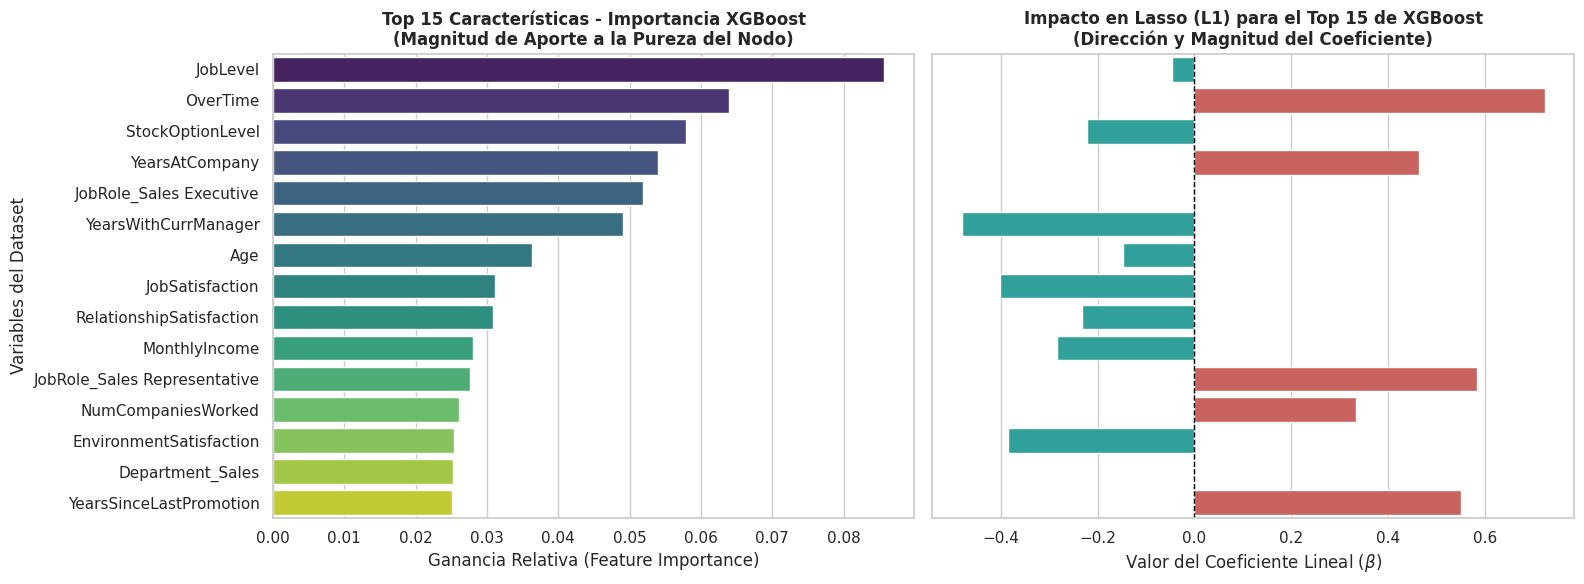

In [ ]:
# Extraer el Top 15 de variables según la importancia de XGBoost
df_top15_xgb = df_explicabilidad.sort_values(by='Importancia_XGBoost', ascending=False).head(15).copy()

# Configurar el espacio de la figura (2 subplots en paralelo)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.set_theme(style="whitegrid")

# --- PANEL IZQUIERDO: IMPORTANCIA DE VARIABLES EN XGBOOST ---
sns.barplot(
    data=df_top15_xgb,
    x='Importancia_XGBoost',
    y='Variable',
    hue='Variable',
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title('Top 15 Características - Importancia XGBoost\n(Magnitud de Aporte a la Pureza del Nodo)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ganancia Relativa (Feature Importance)')
axes[0].set_ylabel('Variables del Dataset')

# --- PANEL DERECHO: COEFICIENTES DE LASSO (L1) PARA ESAS MISMAS VARIABLES ---
# Creamos una paleta condicional para Lasso: Azul si retiene (negativo), Rojo si propicia la fuga (positivo)
colors_lasso = ['#d9534f' if c > 0 else '#20b2aa' if c < 0 else '#777777' for c in df_top15_xgb['Coef_Lasso_L1']]

sns.barplot(
    data=df_top15_xgb,
    x='Coef_Lasso_L1',
    y='Variable',
    hue='Variable',
    palette=colors_lasso,
    legend=False,
    ax=axes[1]
)
# Añadir una línea de referencia en cero para ver claramente la dirección
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Impacto en Lasso (L1) para el Top 15 de XGBoost\n(Dirección y Magnitud del Coeficiente)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Valor del Coeficiente Lineal ($\\beta$)')
axes[1].set_ylabel('') # Eliminamos el label del eje Y porque está compartido con el panel izquierdo

# Ajuste estético final y despliegue
plt.tight_layout()
plt.show()


* El panel izquierdo muestra las variables que más aportan pureza al modelo no lineal (XGBoost), y el panel derecho muestra el impacto y la dirección que el modelo lineal (Lasso) le asigna a esas mismas variables.

* Vemos si las variables que XGBoost considera cruciales para armar sus árboles (como OverTime o JobLevel) también son prioritarias para Lasso.

* En el panel de Lasso, las barras que se extienden a la derecha (Rojo) muestran variables que aumentan el riesgo de que el empleado renuncie, mientras que las barras a la izquierda (Azul) muestran factores que ayudan a retener al personal.